PROJECT 3 AUTHORS:
- MATEUSZ OSAK
- KRZYSZTOF DĄBROWSKI
- SZYMON DOMAŃSKI

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cooler
import cooltools
from scipy.signal import find_peaks
import subprocess
import urllib.request
import seaborn as sns

In [49]:



os.makedirs("./data", exist_ok=True)

# 1. Hi-C jako .hic (filtered, MAPQ>=30, ~2 GB)
hic_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63525/suppl/GSE63525_IMR90_combined_30.hic"

# 2. Referencja TAD-ów 
tads_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63525/suppl/GSE63525_IMR90_Arrowhead_domainlist.txt.gz"

# 3. Referencja pętli (HiCCUPS) - na sekcję 5
loops_url = "https://ftp.ncbi.nlm.nih.gov/geo/series/GSE63nnn/GSE63525/suppl/GSE63525_IMR90_HiCCUPS_looplist.txt.gz"

for url in [hic_url, tads_url, loops_url]:
    
    fname = os.path.join("./data", url.split("/")[-1])
    if not os.path.exists(fname):
      print(f"Pobieram {url.split('/')[-1]}...")
      urllib.request.urlretrieve(url, fname)
      print(f"  OK: {fname} ({os.path.getsize(fname)/1e6:.0f} MB)")

In [50]:
hic_path = "./data/GSE63525_IMR90_combined_30.hic"

cool_25k  = "./data/IMR90_25k.cool"
cool_250k = "./data/IMR90_250k.cool"


if not os.path.exists(cool_25k):
    subprocess.run(["hic2cool", "convert", hic_path, cool_25k, "-r", "25000"], check=True)


if not os.path.exists(cool_250k):
    subprocess.run(["hic2cool", "convert", hic_path, cool_250k, "-r", "250000"], check=True)



In [51]:
mcool_path = "./data/IMR90_25k.cool"

Pobrany plik to in situ Hi-C dla linii IMR-90 (ludzkie fibroblasty płucne) z publikacji Rao et al., Cell 2014 (GSE63525). Pełnogenomowe, MAPQ≥30, mapowanie do hg19.

## 1. Hi-C Data Visualization

In [52]:
chrom = "17"
start = 30_000_000
end   = 35_000_000
region = f"{chrom}:{start}-{end}"

clr = cooler.Cooler(mcool_path)
print(clr.chromsizes)

mat = clr.matrix(balance=False).fetch(region).astype(float)
print("Kształt macierzy:", mat.shape)
print(f"Min: {mat.min():.0f}, Max: {mat.max():.0f}, Mediana: {np.median(mat):.0f}")

name
1     249250621
2     243199373
3     198022430
4     191154276
5     180915260
6     171115067
7     159138663
8     146364022
9     141213431
10    135534747
11    135006516
12    133851895
13    115169878
14    107349540
15    102531392
16     90354753
17     81195210
18     78077248
19     59128983
20     63025520
21     48129895
22     51304566
X     155270560
Y      59373566
MT        16569
Name: length, dtype: int32
Kształt macierzy: (200, 200)
Min: 0, Max: 3670, Mediana: 6


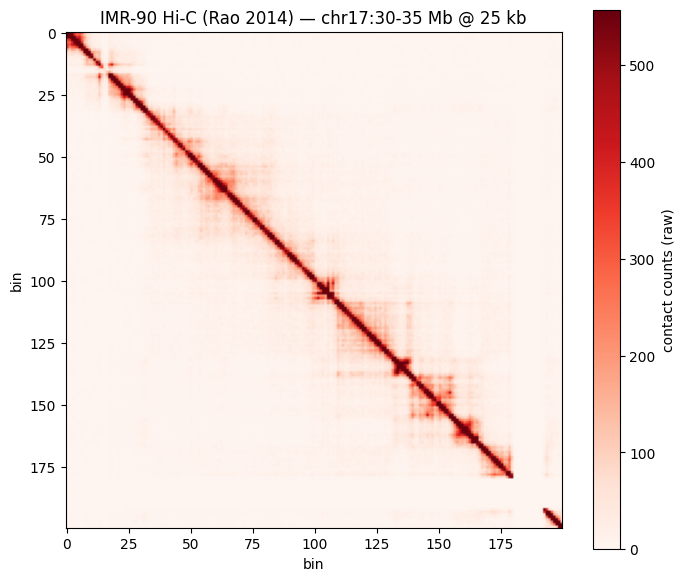

In [53]:
plt.figure(figsize=(8, 7))

vmax = np.nanpercentile(mat, 99)

plt.imshow(mat, cmap="Reds", vmax=vmax)
plt.colorbar(label="contact counts (raw)")
plt.title(f"IMR-90 Hi-C (Rao 2014) — chr{chrom}:{start/1e6:.0f}-{end/1e6:.0f} Mb @ 25 kb")
plt.xlabel("bin")
plt.ylabel("bin")
plt.show()

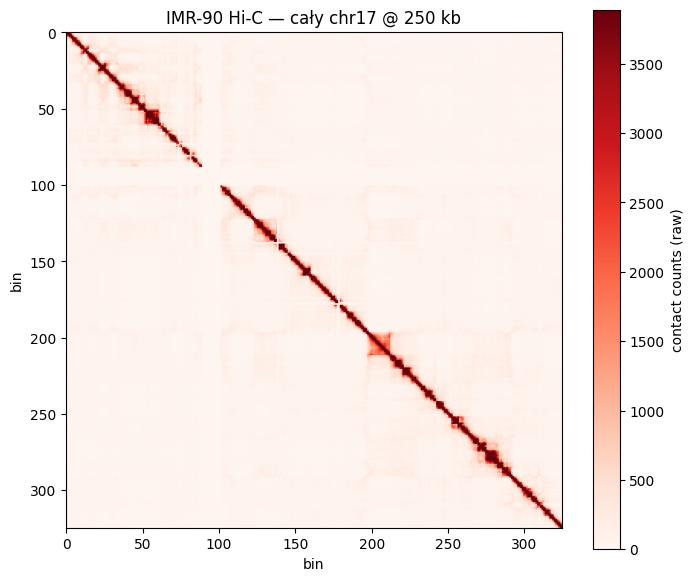

In [54]:
clr_low = cooler.Cooler("./data/IMR90_250k.cool")  
mat_whole = clr_low.matrix(balance=False).fetch(chrom).astype(float)

plt.figure(figsize=(8, 7))
plt.imshow(mat_whole, cmap="Reds", vmax=np.nanpercentile(mat_whole, 99))
plt.colorbar(label="contact counts (raw)")
plt.title(f"IMR-90 Hi-C — cały chr{chrom} @ 250 kb")
plt.xlabel("bin"); plt.ylabel("bin")
plt.show()

Skupmy się na  rozdzielczości 25 kb, mamy tam bardziej widoczne TADY.

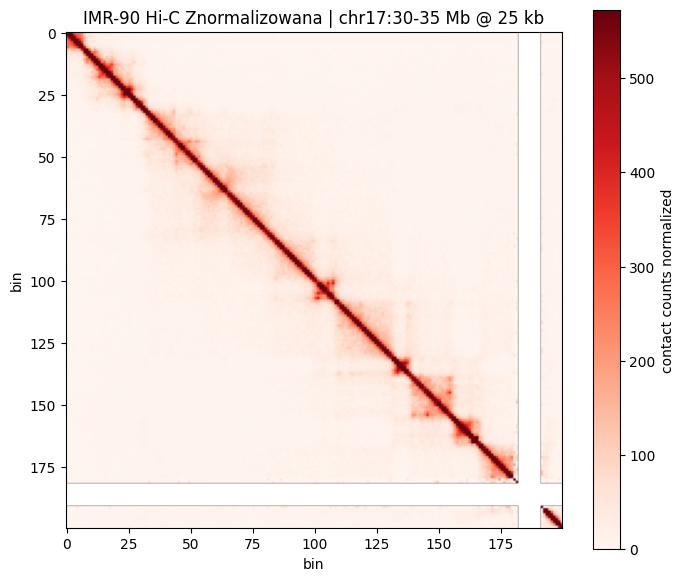

In [55]:


mat_norm = clr.matrix(balance='KR').fetch(region).astype(float)


plt.figure(figsize=(8, 7))

vmax_norm = np.nanpercentile(mat_norm, 99)

plt.imshow(mat_norm, cmap="Reds", vmax=vmax_norm)
plt.colorbar(label=f"contact counts normalized")
plt.title(f"IMR-90 Hi-C Znormalizowana | chr{chrom}:{start/1e6:.0f}-{end/1e6:.0f} Mb @ 25 kb")
plt.xlabel("bin")
plt.ylabel("bin")
plt.show()

Wnioski:


## 2 TAD Detection

In [56]:


def compute_insulation_score(mat, window=5):
    """Compute insulation score for TAD boundary detection."""
    n = mat.shape[0]
    insulation = np.zeros(n)
    for i in range(n):
        s = max(0, i - window)
        e = min(n, i + window + 1)
        submat = mat[s:e, s:e]
        insulation[i] = submat.sum()
    return insulation


def detect_tad_boundaries(insulation, smooth=3):
    """Detect TAD boundaries as local minima in insulation score."""
    n = len(insulation)
    if smooth:
        ins_cs = np.cumsum(insulation)
        ins_cs[smooth:] = ins_cs[smooth:] - ins_cs[:-smooth]
        insulation[smooth // 2:-smooth // 2 + 1] = ins_cs[smooth - 1:] / smooth
    boundaries = [
        i for i in range(1, n - 1)
        if insulation[i] < insulation[i - 1] and insulation[i] < insulation[i + 1]
    ]
    return boundaries


def get_tad_regions(boundaries, n_bins):
    """Convert TAD boundaries to a list of TAD regions (start, end)."""
    regions = []
    s = 0
    for b in boundaries:
        regions.append((s, b))
        s = b
    regions.append((s, n_bins))
    return regions

In [57]:
mat_clean = np.nan_to_num(mat)

# Insulation z większym oknem + filtr na głębokość minimum
ins = compute_insulation_score(mat_clean, window=10)  # było 5 -> daj 10

# Wykryj granice + odfiltruj słabe
raw_boundaries = detect_tad_boundaries(ins.copy(), smooth=3)

# Filtr: minimum musi być wyraźnie głębsze niż otoczenie
# (prosty próg: różnica do mediany sąsiadów min. 5% globalnej amplitudy)
threshold = 0.01 * (np.max(ins) - np.min(ins))

boundaries_ins = []
for b in raw_boundaries:
    # głębokość minimum = średnia sąsiadów - wartość w minimum
    neighbors = np.concatenate([ins[max(0, b-5):b], ins[b+1:b+6]])
    depth = neighbors.mean() - ins[b]
    if depth > threshold:
        boundaries_ins.append(b)

print(f"Insulation:  {len(boundaries_ins)} ")

Insulation:  10 


In [58]:
def directionality_index(matrix, window=10):
    """
    Dla każdego binu i:
      A = suma kontaktów w lewo (i-window do i)
      B = suma kontaktów w prawo (i do i+window)
      DI = znak(B-A) * skala
    DI silnie ujemne -> koniec TAD, silnie dodatnie -> początek nowego TAD.
    Granica = zmiana znaku z minusa na plus.
    """
    n = matrix.shape[0]
    di = np.zeros(n)
    for i in range(window, n - window):
        A = matrix[i, i - window:i].sum()
        B = matrix[i, i + 1:i + window + 1].sum()
        E = (A + B) / 2
        if E > 0:
            di[i] = ((B - A) / (B + A + 1e-10)) * (((A - E) ** 2 + (B - E) ** 2) / E)
    return di


# Directionality z filtrem na siłę
di = directionality_index(mat_clean, window=10)

# Granice = zmiana znaku, ALE wymagamy żeby DI był wyraźnie ujemny przed
# i wyraźnie dodatni po (nie tylko drobne wahnięcie koło zera)
di_threshold = 0.1 * np.std(di)

boundaries_di = []
for i in range(3, len(di) - 3):
    # przed granicą DI silnie ujemne (średnia 3 poprzednich)
    before = di[i-3:i].mean()
    # po granicy DI silnie dodatnie
    after = di[i:i+3].mean()
    if before < -di_threshold and after > di_threshold:
        boundaries_di.append(i)

print(f"Directionality: {len(boundaries_di)} granic po filtrze")

Directionality: 9 granic po filtrze


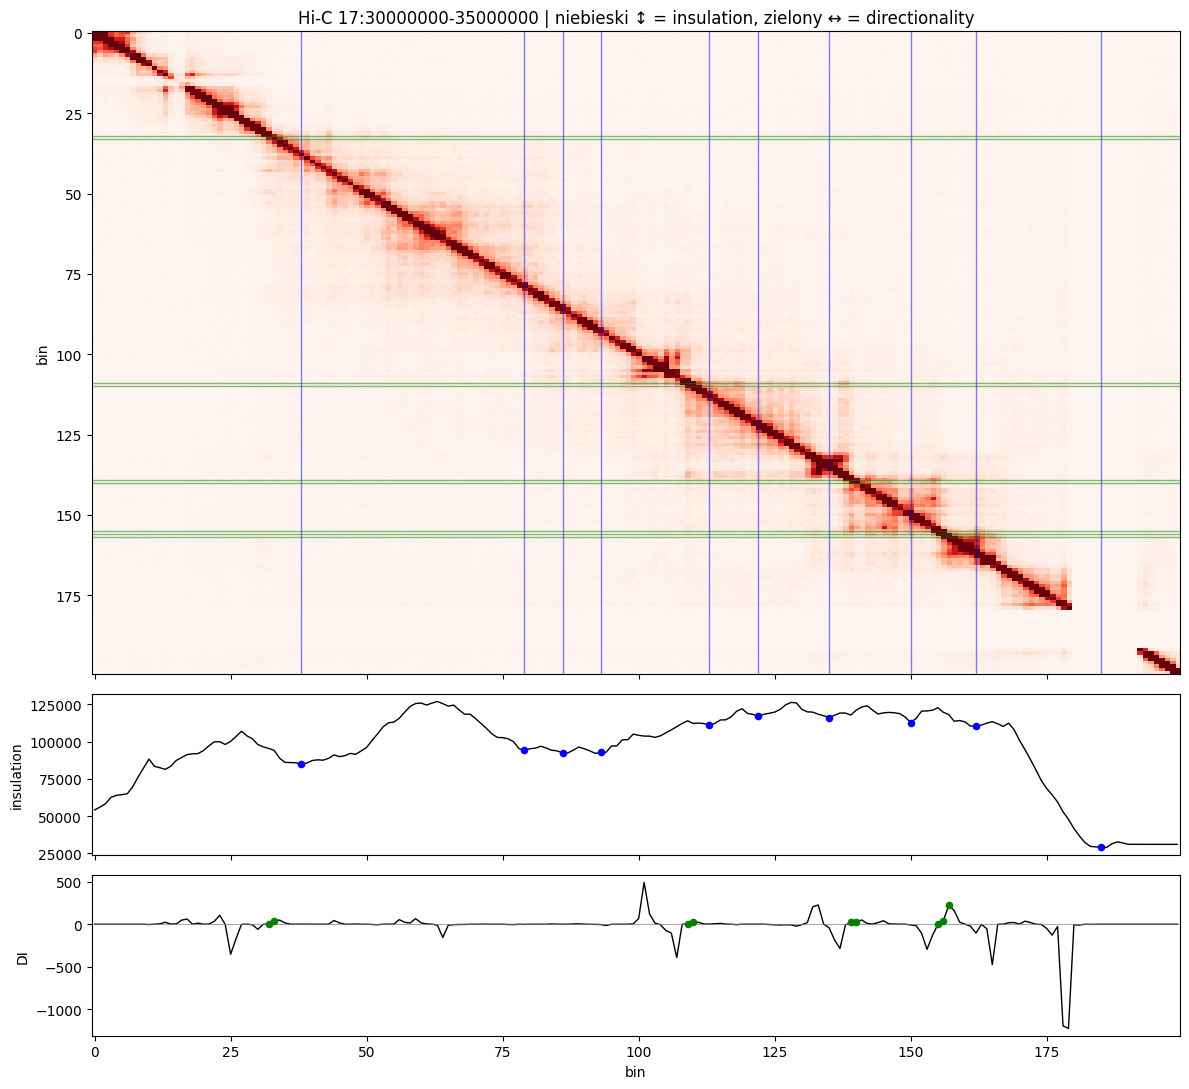

In [59]:
fig, axes = plt.subplots(3, 1, figsize=(12, 11),
                         gridspec_kw={'height_ratios': [4, 1, 1]},
                         sharex=True)

# Heatmapa Hi-C z granicami z obu metod
axes[0].imshow(mat, cmap='Reds', vmax=np.nanpercentile(mat, 99), aspect='auto')
for b in boundaries_ins:
    axes[0].axvline(b, color='blue', alpha=0.5, lw=1)
for b in boundaries_di:
    axes[0].axhline(b, color='green', alpha=0.5, lw=1)
axes[0].set_title(f"Hi-C {region} | niebieski ↕ = insulation, zielony ↔ = directionality")
axes[0].set_ylabel("bin")

# Profil insulation score
axes[1].plot(ins, color='black', lw=1)
axes[1].scatter(boundaries_ins, ins[boundaries_ins], color='blue', s=20, zorder=5)
axes[1].set_ylabel("insulation")

# Profil directionality index
axes[2].plot(di, color='black', lw=1)
axes[2].axhline(0, color='gray', lw=0.5)
axes[2].scatter(boundaries_di, [di[i] for i in boundaries_di], color='green', s=20, zorder=5)
axes[2].set_ylabel("DI")
axes[2].set_xlabel("bin")

plt.tight_layout()
plt.show()

In [60]:
import pandas as pd

# Wczytaj TAD-y referencyjne Rao 2014 (Arrowhead)
tads_ref = pd.read_csv("./data/GSE63525_IMR90_Arrowhead_domainlist.txt.gz", sep="\t")

# Sprawdź jak nazywają się kolumny (pierwszy raz)
print(tads_ref.columns.tolist())
print(tads_ref.head())
# Rao 2014 używa "17" bez prefiksu "chr"
target_chrom = chrom.replace("chr", "")  # "chr17" -> "17", "17" -> "17"

# Filtruj TAD-y do naszego regionu
tads_in_region = tads_ref[
    (tads_ref["chr1"].astype(str) == target_chrom) &
    (tads_ref["x1"] >= start) &
    (tads_ref["x2"] <= end)
].copy()

print(f"TAD-ów referencyjnych w regionie: {len(tads_in_region)}")

# Granice TAD = unikalne pozycje start i end każdego TAD-u, przeliczone na biny
resolution = 25_000
ref_positions_bp = sorted(set(
    list(tads_in_region["x1"]) + list(tads_in_region["x2"])
))

ref_boundaries = [(pos - start) // resolution for pos in ref_positions_bp]
ref_boundaries = [b for b in ref_boundaries if 0 <= b < mat.shape[0]]

print(f"Granic referencyjnych (w binach): {len(ref_boundaries)}")

['chr1', 'x1', 'x2', 'chr2', 'y1', 'y2', 'color', 'f1', 'f2', 'f3', 'f4', 'f5']
  chr1         x1         x2 chr2         y1         y2      color       f1  \
0    1  120740000  121360000    1  120740000  121360000  255,255,0  0.66255   
1    1  104330000  106930000    1  104330000  106930000  255,255,0  0.44089   
2    1  101950000  104140000    1  101950000  104140000  255,255,0  0.59225   
3    1  101960000  103790000    1  101960000  103790000  255,255,0  1.06700   
4    1  152470000  153270000    1  152470000  153270000  255,255,0  0.75464   

        f2       f3       f4       f5  
0  0.36108  0.34074  0.49532  0.57024  
1  0.34166  0.27985  0.51278  0.44290  
2  0.34728  0.24742  0.59500  0.47056  
3  0.18512  0.30434  0.79611  0.56940  
4  0.13764  0.21023  0.42812  0.73188  
TAD-ów referencyjnych w regionie: 14
Granic referencyjnych (w binach): 27


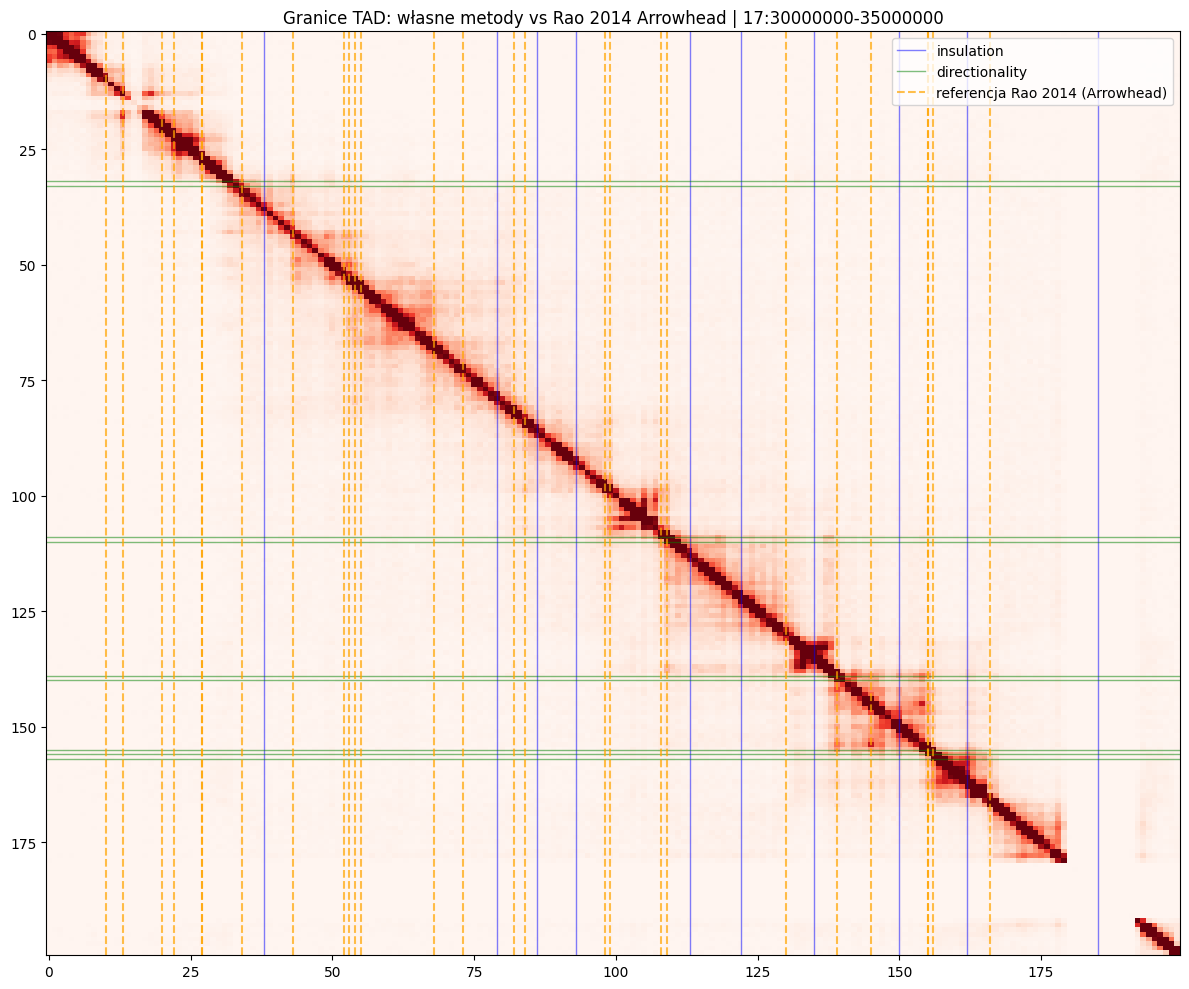

In [61]:
fig, ax = plt.subplots(figsize=(12, 10))
ax.imshow(mat, cmap='Reds', vmax=np.nanpercentile(mat, 99), aspect='auto')

for i, b in enumerate(boundaries_ins):
    ax.axvline(b, color='blue', alpha=0.5, lw=1,
               label='insulation' if i == 0 else '')
for i, b in enumerate(boundaries_di):
    ax.axhline(b, color='green', alpha=0.5, lw=1,
               label='directionality' if i == 0 else '')
for i, b in enumerate(ref_boundaries):
    ax.axvline(b, color='orange', alpha=0.7, lw=1.5, ls='--',
               label='referencja Rao 2014 (Arrowhead)' if i == 0 else '')

ax.legend(loc='upper right')
ax.set_title(f"Granice TAD: własne metody vs Rao 2014 Arrowhead | {region}")
plt.tight_layout()
plt.show()

In [62]:
def precision_recall(predicted, reference, tol=1):
    """tol=1 przy 25 kb = tolerancja ±25 kb między granicami."""
    if len(predicted) == 0 or len(reference) == 0:
        return 0.0, 0.0
    matched_pred = sum(any(abs(p - r) <= tol for r in reference) for p in predicted)
    matched_ref  = sum(any(abs(r - p) <= tol for p in predicted) for r in reference)
    return matched_pred / len(predicted), matched_ref / len(reference)


p_ins, r_ins = precision_recall(boundaries_ins, ref_boundaries, tol=1)
p_di,  r_di  = precision_recall(boundaries_di,  ref_boundaries, tol=1)

print(f"{'Metoda':<25} {'# granic':>10} {'precision':>12} {'recall':>10}")
print("-" * 60)
print(f"{'Insulation (lab)':<25} {len(boundaries_ins):>10} {p_ins:>11.0%} {r_ins:>10.0%}")
print(f"{'Directionality index':<25} {len(boundaries_di):>10} {p_di:>11.0%} {r_di:>10.0%}")
print(f"{'Referencja (Rao 2014)':<25} {len(ref_boundaries):>10}")

Metoda                      # granic    precision     recall
------------------------------------------------------------
Insulation (lab)                  10          0%         0%
Directionality index               9         89%        26%
Referencja (Rao 2014)             27


=== STATYSTYKI ROZKŁADU WIELKOŚCI DOMEN TAD ===


,Metoda,Liczba TAD-ów,Średnia (Mb),Mediana (Mb),Min (Mb),Max (Mb)
0,Insulation Score,11,0.455,0.375,0.175,1.025
1,Directionality Index,10,0.500,0.200,0.025,1.900
2,Rao 2014 (Ref),14,0.336,0.285,0.130,0.700


/var/folders/45/qvg2y71577g1pl9tyk8p0p640000gn/T/ipykernel_2335/3121983085.py:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=labels, y=combined_lengths, palette=["#9bc2e6", "#a9d18e", "#f8cbad"], ax=axes[1], width=0.5)


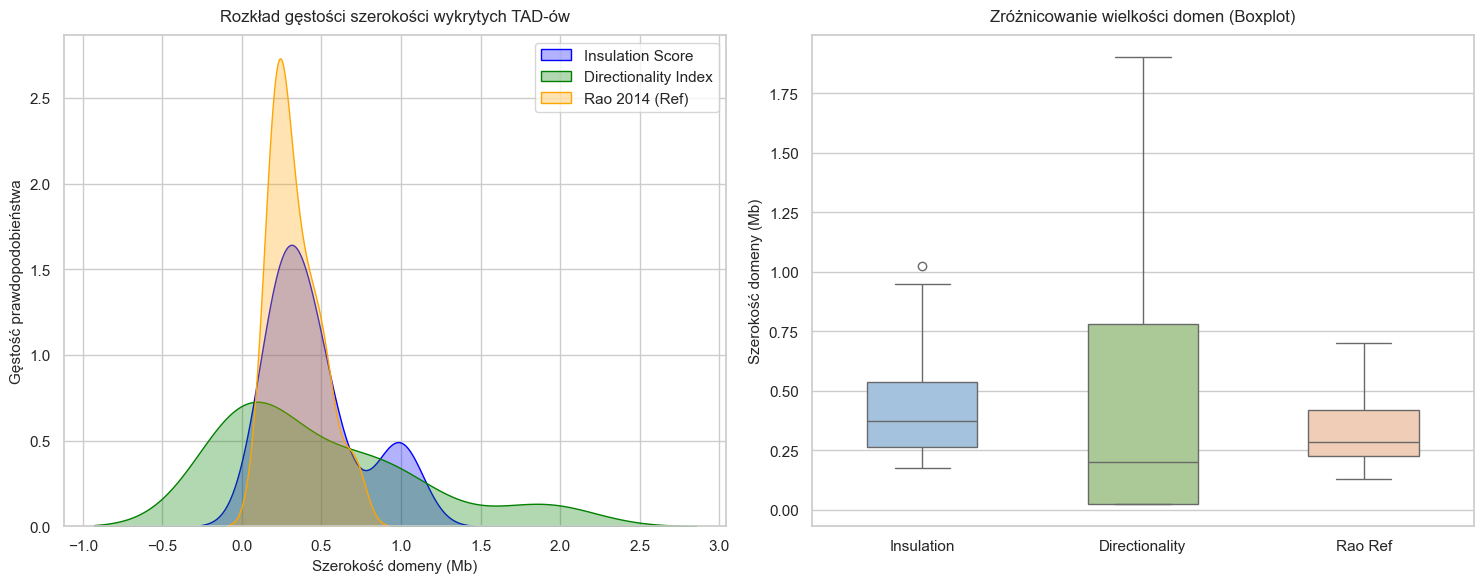

In [ ]:





res_mb = 25_000 / 1e6  

def get_tad_lengths(boundaries, total_bins, res):
    full_borders = sorted(list(set([0] + boundaries + [total_bins])))
    return [(full_borders[i+1] - full_borders[i]) * res for i in range(len(full_borders)-1)]

total_bins = mat.shape[0]

lengths_ins = get_tad_lengths(boundaries_ins, total_bins, res_mb)
lengths_di  = get_tad_lengths(boundaries_di, total_bins, res_mb)

lengths_ref = ((tads_in_region["x2"] - tads_in_region["x1"]) / 1e6).tolist()

df_stats = pd.DataFrame({
    "Metoda": ["Insulation Score", "Directionality Index", "Rao 2014 (Ref)"],
    "Liczba TAD-ów": [len(lengths_ins), len(lengths_di), len(lengths_ref)],
    "Średnia (Mb)": [np.mean(lengths_ins), np.mean(lengths_di), np.mean(lengths_ref)],
    "Mediana (Mb)": [np.median(lengths_ins), np.median(lengths_di), np.median(lengths_ref)],
    "Min (Mb)": [np.min(lengths_ins), np.min(lengths_di), np.min(lengths_ref)],
    "Max (Mb)": [np.max(lengths_ins), np.max(lengths_di), np.max(lengths_ref)]
}).round(3)

print("=== STATYSTYKI ROZKŁADU WIELKOŚCI DOMEN TAD ===")
display(df_stats) 


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))


sns.kdeplot(lengths_ins, fill=True, color="blue", label="Insulation Score", ax=axes[0], alpha=0.3, bw_adjust=0.8)
sns.kdeplot(lengths_di, fill=True, color="green", label="Directionality Index", ax=axes[0], alpha=0.3, bw_adjust=0.8)
sns.kdeplot(lengths_ref, fill=True, color="orange", label="Rao 2014 (Ref)", ax=axes[0], alpha=0.3, bw_adjust=0.8)
axes[0].set_title("Rozkład gęstości szerokości wykrytych TAD-ów", fontsize=12, pad=10)
axes[0].set_xlabel("Szerokość domeny (Mb)", fontsize=11)
axes[0].set_ylabel("Gęstość prawdopodobieństwa", fontsize=11)
axes[0].legend()


combined_lengths = lengths_ins + lengths_di + lengths_ref
labels = (["Insulation"] * len(lengths_ins) + 
          ["Directionality"] * len(lengths_di) + 
          ["Rao Ref"] * len(lengths_ref))

sns.boxplot(x=labels, y=combined_lengths, palette=["#9bc2e6", "#a9d18e", "#f8cbad"], ax=axes[1], width=0.5)
axes[1].set_title("Zróżnicowanie wielkości domen (Boxplot)", fontsize=12, pad=10)
axes[1].set_ylabel("Szerokość domeny (Mb)", fontsize=11)
axes[1].set_xlabel("")

plt.tight_layout()
plt.show()

## 3. CTCF analysis

In [64]:
# totalnie nie wiem jak to zrobić

## 4. Integration with 1D data.

In [65]:
# 1d data download

In [66]:
# data vis

In [67]:
# TAD border check

In [68]:
# simple analisis wzbogacanie???

## 5. Chromatin loops detection 

In [69]:
#